# Bank Marketing - Modeling

**DATA 4950 Week 12 Demo**

## What We Will Cover


1. Load preprocessed data
2. Baseline model (Simple Train/Test)
3. Advanced models (Simple Train/Test)
4. Cross-validation
5. Hyperparameter tuning (GridSearchCV)
6. Final model comparision
7. Save the best model

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [2]:
# load data from feature engineering notebook
X_train = pd.read_csv('../data/modeling/X_train.csv')
X_test = pd.read_csv('../data/modeling/X_test.csv')
y_train = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test = pd.read_csv('../data/modeling/y_test.csv').squeeze()

## save WITH SMOTE
X_train_smote = pd.read_csv('../data/modeling/X_train_smote.csv')
y_train_smote = pd.read_csv('../data/modeling/y_train_smote.csv').squeeze()

print(f'Training (original): {X_train.shape}')
print(f'Training (SMOTE):    {X_train_smote.shape}')
print(f'Test:                {X_test.shape}')
print(f'\nClass distribution (train): {y_train.value_counts().to_dict()}')
print(f'Class distribution (test):  {y_test.value_counts().to_dict()}')

Training (original): (32940, 51)
Training (SMOTE):    (58458, 51)
Test:                (8236, 51)

Class distribution (train): {0: 29229, 1: 3711}
Class distribution (test):  {0: 7308, 1: 928}


## PART 1: Basic Models

Start simple. Build complexity gradually.

### model 1: logistic regression (baseline)

In [3]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=4950)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=4950)

In [4]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]   # probability of class 1 (yes)

In [5]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7308
         Yes       0.67      0.22      0.33       928

    accuracy                           0.90      8236
   macro avg       0.79      0.60      0.64      8236
weighted avg       0.88      0.90      0.88      8236



In [6]:
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

ROC-AUC: 0.7964


In [7]:
lr_auc_baseline = roc_auc_score(y_test, y_prob)
lr_prob_baseline = y_prob

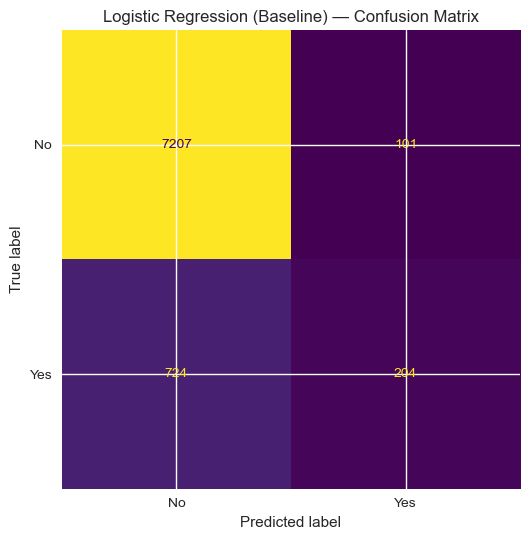

In [8]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['No', 'Yes'],
                                        colorbar=False)
plt.title('Logistic Regression (Baseline) — Confusion Matrix')
plt.tight_layout()
plt.show()

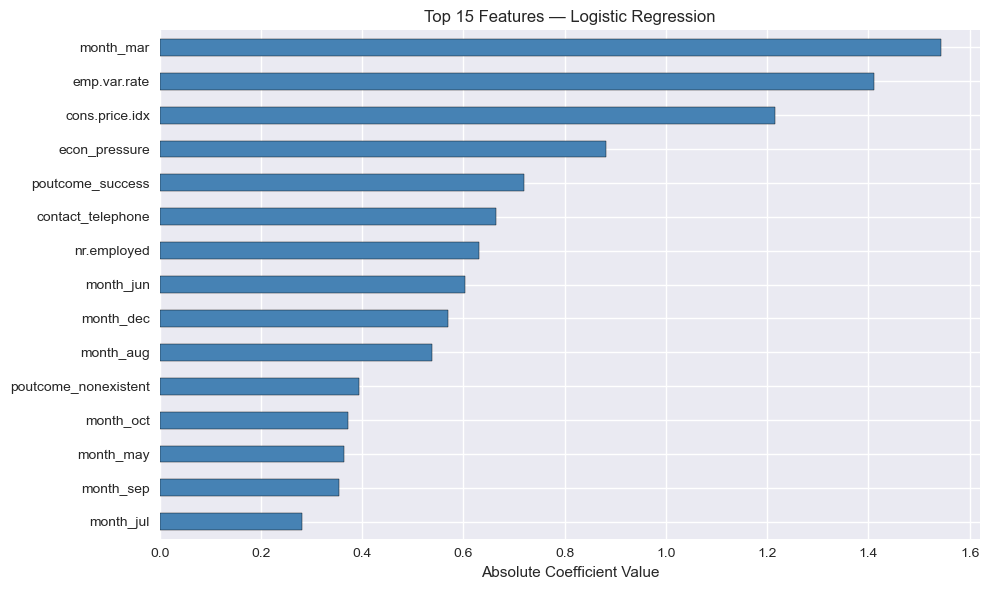

In [9]:
importances = pd.Series(np.abs(lr.coef_[0]), index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 15 Features — Logistic Regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### model 2: decision tree

### model 3: SVM (baseline)

In [17]:
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=4950)
svm.fit(X_train, y_train)

SVC(probability=True, random_state=4950)

In [18]:
y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:, 1]

In [19]:
print('=== SVM (Baseline) ===')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

svm_auc_baseline = roc_auc_score(y_test, y_prob)
svm_prob_baseline = y_prob

=== SVM (Baseline) ===
              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7308
         Yes       0.68      0.25      0.36       928

    accuracy                           0.90      8236
   macro avg       0.80      0.62      0.65      8236
weighted avg       0.89      0.90      0.88      8236

ROC-AUC: 0.6930


### model 4: random forest

### model 5: gradient boosting 

In [27]:
baseline_summary = pd.DataFrame({
    'Model':   ['Logistic Regression', 'Decision Tree', 'SVM', 'Random Forest'],
    'ROC-AUC': [round(lr_auc_baseline, 4),
                round(dt_auc_baseline, 4),
                round(svm_auc_baseline, 4),
                round(rf_auc_baseline, 4)]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('Baseline Model Comparison:')
print(baseline_summary)

Baseline Model Comparison:
                 Model  ROC-AUC
0  Logistic Regression   0.7964
1        Random Forest   0.7824
2                  SVM   0.6930
3        Decision Tree   0.6371


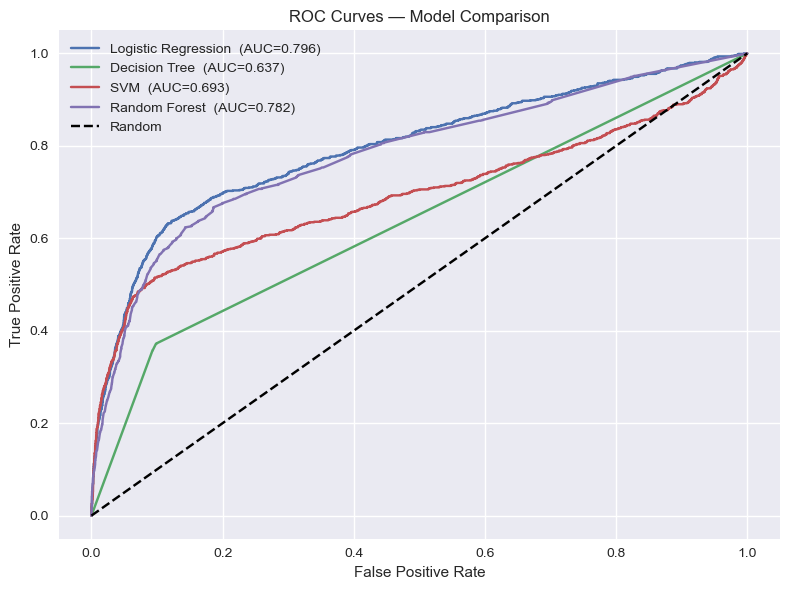

In [28]:
## compare ROC curves for all models

plt.figure(figsize=(8, 6))

for name, prob in [('Logistic Regression', lr_prob_baseline),
                   ('Decision Tree',       dt_prob_baseline),
                   ('SVM',       svm_prob_baseline),
                   ('Random Forest',       rf_prob_baseline)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


 we trained Section 2 models on original data
 
 now retrain the same models on SMOTE data and compare
 
test set stays the same — only training data changes

### Introduce StratifiedKFold

The Problem: Can We Trust One Split?

In [46]:
## our test AUC came from ONE specific train/test split
## what if Random Forest got lucky and Gradient Boosting got unlucky?
## the difference below looks small — is it real or just noise?

print(f'Random Forest AUC:      {rf_auc_baseline:.4f}')
print(f'Gradient Boosting AUC:  {gb_auc_baseline:.4f}')
print(f'Difference:             {abs(rf_auc_baseline - gb_auc_baseline):.4f}  <- is this real or noise?')
print()
print('Solution: cross-validation gives us mean ± std across 5 splits')
print('         so we can see if the gap is consistent or accidental')

Random Forest AUC:      0.7824
Gradient Boosting AUC:  0.7760
Difference:             0.0064  <- is this real or noise?

Solution: cross-validation gives us mean ± std across 5 splits
         so we can see if the gap is consistent or accidental


In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [48]:
## stratified = each fold preserves the class ratio (important for imbalanced data)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=4950)

## quick CV check on our two best models before tuning
for name, model in [('Random Forest', rf), ('Gradient Boosting', gb)]:
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name}')
    print(f'  Fold scores: {np.round(scores, 4)}')
    print(f'  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')
    print()

Random Forest
  Fold scores: [0.9797 0.9775 0.9769 0.9789 0.9799]
  Mean: 0.9786  Std: 0.0012

Gradient Boosting
  Fold scores: [0.9352 0.926  0.9268 0.9304 0.9374]
  Mean: 0.9311  Std: 0.0045



In [49]:
### Prepare Fair Baseline for Tuning Comparison

## Cell 40 already ran: X_train = X_train_smote
## now retrain baselines with default params on the same SMOTE data

lr_default   = LogisticRegression(max_iter=1000, random_state=4950).fit(X_train, y_train)
dt_default   = DecisionTreeClassifier(random_state=4950).fit(X_train, y_train)
rf_default   = RandomForestClassifier(n_estimators=100, random_state=4950).fit(X_train, y_train)
gb_default   = GradientBoostingClassifier(random_state=4950).fit(X_train, y_train)
lgbm_default = LGBMClassifier(random_state=4950, verbose=-1).fit(X_train, y_train)

print('Baselines retrained on SMOTE data — ready for fair comparison')

Baselines retrained on SMOTE data — ready for fair comparison


In [50]:
lr_auc_default   = roc_auc_score(y_test, lr_default.predict_proba(X_test)[:, 1])
dt_auc_default   = roc_auc_score(y_test, dt_default.predict_proba(X_test)[:, 1])
rf_auc_default   = roc_auc_score(y_test, rf_default.predict_proba(X_test)[:, 1])
gb_auc_default   = roc_auc_score(y_test, gb_default.predict_proba(X_test)[:, 1])
lgbm_auc_default = roc_auc_score(y_test, lgbm_default.predict_proba(X_test)[:, 1])

In [51]:
smote_baseline_aucs = {
    'Logistic Regression': roc_auc_score(y_test, lr_default.predict_proba(X_test)[:, 1]),
    'Decision Tree':       roc_auc_score(y_test, dt_default.predict_proba(X_test)[:, 1]),
    'Random Forest':       roc_auc_score(y_test, rf_default.predict_proba(X_test)[:, 1]),
    'Gradient Boosting':   roc_auc_score(y_test, gb_default.predict_proba(X_test)[:, 1]),
    'LightGBM':            roc_auc_score(y_test, lgbm_default.predict_proba(X_test)[:, 1]),
}
print('SMOTE default AUCs (used as fair baseline for tuning gain):')
for name, auc in smote_baseline_aucs.items():
    print(f'  {name:<25} {auc:.4f}')

SMOTE default AUCs (used as fair baseline for tuning gain):
  Logistic Regression       0.7378
  Decision Tree             0.6403
  Random Forest             0.7758
  Gradient Boosting         0.7760
  LightGBM                  0.7862


## Hyperparameter Tuning with GridSearchCV

In [52]:
from sklearn.model_selection import GridSearchCV

### tuning: logistic regression

### tuning: decision tree

### tuning: SVM

In [59]:
## C controls the margin width — larger C = fits training data more tightly
## kernel='rbf' handles non-linear boundaries; 'linear' is faster and simpler
## gamma controls how far the influence of a single training example reaches
# svm_param_grid = {
#     'C':      [0.1, 1, 10],
#     'kernel': ['rbf', 'linear'],
#     'gamma':  ['scale', 'auto']
# }

# svm_grid = GridSearchCV(
#     SVC(probability=True, random_state=4950),
#     param_grid=svm_param_grid,
#     cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
# )
# svm_grid.fit(X_train, y_train)

# print(f'Best params: {svm_grid.best_params_}')
# print(f'Best CV AUC: {svm_grid.best_score_:.4f}')

In [60]:
# ## inspect top 5 SVM combinations

# svm_cv = (pd.DataFrame(svm_grid.cv_results_)
#             [['param_C', 'param_kernel', 'param_gamma',
#               'mean_test_score', 'std_test_score', 'rank_test_score']]
#             .sort_values('rank_test_score')
#             .head(5)
#             .round(4)
#             .reset_index(drop=True))

# print('Top 5 SVM parameter combinations:')
# print(svm_cv)

In [61]:
# ## evaluate tuned SVM

# y_pred = svm_grid.best_estimator_.predict(X_test)
# y_prob = svm_grid.best_estimator_.predict_proba(X_test)[:, 1]

# print('=== SVM (Tuned) ===')
# print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
# print(f'Baseline AUC: {svm_auc_default:.4f}')
# print(f'Tuned AUC:    {roc_auc_score(y_test, y_prob):.4f}')
# print(f'Gain:         {roc_auc_score(y_test, y_prob) - svm_auc_default:+.4f}')

# svm_auc_tuned  = roc_auc_score(y_test, y_prob)
# svm_prob_tuned = y_prob

### tuning: random forest

### tuning: gradient boosting

## Model Selection

## Save Best Model

In [77]:
## save best model
import pickle, os
os.makedirs('../models', exist_ok=True)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved:  ../models/best_model.pkl')
print(f'Model:  {type(best_model).__name__}')
print(f'Params: {rf_grid.best_params_}')

Saved:  ../models/best_model.pkl
Model:  RandomForestClassifier
Params: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
